# Phishing Website Detection — Model Training & Selection

**Goal:** build a classifier that decides whether a website is **phishing** or **legitimate** from 30 URL / HTML / domain features, and find the *best* model in a fair, leak-free way.

This notebook continues from `01_EDA.ipynb`. The EDA told us what to do here:

| EDA finding | What we do in this notebook |
|---|---|
| 47 % of rows are exact duplicates | remove them **before** splitting (and prove why with an experiment) |
| Classes are mildly unbalanced | stratified split + stratified CV, no resampling |
| Features are categorical codes with non-monotonic effects | compare **ordinal vs one-hot encoding** and pick the best encoding per model family |
| Strong feature interactions | include tree ensembles / boosting next to linear, kernel, neighbour and neural models |

**Workflow**

1. Setup → 2. Load & define target → 3. Duplicates experiment & cleaning → 4. Train/test split → 5. Feature encoding → 6. Baseline comparison of 12 models (cross-validation) → 7. Hyper-parameter tuning (GridSearchCV + RandomizedSearchCV) → 8. Ensembles (Voting, Stacking) → 9. Model selection → 10. Final evaluation on the untouched test set → 11. Diagnostics (ROC, importance, learning curve) → 12. Feature selection check → 13. Decision threshold → 14. Save the model.

**Requirements:** `pip install pandas numpy scikit-learn matplotlib seaborn scipy xgboost lightgbm joblib`

> **Golden rule used throughout:** the *test set is touched only once, at the end*. All choices (encoding, model, hyper-parameters) are made with cross-validation on the training set.

## 1. Setup

**What we do:** import libraries and fix global settings — random seed (reproducibility), the CV strategy (5-fold **stratified** so each fold keeps the class ratio) and the number of random-search iterations.

**Tip:** if tuning takes too long on your machine, lower `N_ITER`; if you have many CPU cores, raise it.

In [7]:
import time, warnings, joblib
from functools import partial
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from scipy.stats import randint, uniform, loguniform

from sklearn.base import clone
from sklearn.model_selection import (train_test_split, StratifiedKFold, cross_validate, cross_val_predict,
                                     GridSearchCV, RandomizedSearchCV, learning_curve)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import BernoulliNB
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier,
                              AdaBoostClassifier, VotingClassifier, StackingClassifier)
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report, RocCurveDisplay)
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 50); pd.set_option("display.width", 200)

DATA_FILE    = Path("Network_data") / "phisingData.csv"
search_roots = [Path.cwd(), *Path.cwd().parents]
DATA_PATH    = next((root / DATA_FILE for root in search_roots if (root / DATA_FILE).exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(f"Could not find {DATA_FILE} from {Path.cwd()} or its parent directories")

RANDOM_STATE = 42
N_JOBS       = -1                     # use all CPU cores
N_ITER       = 20                     # random-search iterations per model
CV           = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

## 2. Load the data and define the target

**What we do:** load the CSV and convert the target `Result` (`-1` = phishing, `1` = legitimate) into a conventional 0/1 column **`is_phishing`** where **1 = phishing**.

**Why:** phishing is the class we want to *catch*, so it should be the **positive class**. Then *recall* = "what share of phishing sites do we catch", *precision* = "when we raise an alarm, how often are we right", and F1 / ROC-AUC are computed for the class that matters.

In [8]:
raw = pd.read_csv(DATA_PATH)
raw["is_phishing"] = (raw["Result"] == -1).astype(int)     # 1 = phishing, 0 = legitimate
raw = raw.drop(columns="Result")
FEATURES = [c for c in raw.columns if c != "is_phishing"]

print("Shape:", raw.shape, "| missing values:", int(raw.isnull().sum().sum()))
print(raw["is_phishing"].value_counts().rename({1: "phishing", 0: "legitimate"}).to_string())

Shape: (11055, 31) | missing values: 0
is_phishing
legitimate    6157
phishing      4898


> **What we get:** 11,055 rows, 30 feature columns, no missing values. The target is now `is_phishing` (1 = phishing, 0 = legitimate): 4,898 phishing and 6,157 legitimate rows.

## 3. Duplicates — experiment first, then clean

The EDA showed that 47 % of rows are exact duplicates. **Do they really matter?** Let's measure it.

**What we do:** train the same Random Forest twice — once on the raw data (with duplicates) and once on the de-duplicated data — using an ordinary random 80/20 split each time. For every test row we also check whether *the same feature vector* also exists in the training set ("leakage").

**Why:** if the score on the raw data is much higher only because test rows were already seen during training, then the raw-data score is misleading.

In [9]:
def quick_rf_experiment(data, label):
    X, y = data[FEATURES], data["is_phishing"]
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
    train_patterns = set(map(tuple, X_tr.values))
    leak = np.mean([tuple(r) in train_patterns for r in X_te.values])
    rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=N_JOBS).fit(X_tr, y_tr)
    pred = rf.predict(X_te)
    return {"dataset": label, "rows": len(data), "test rows already seen in training": f"{leak:.1%}",
            "test accuracy": accuracy_score(y_te, pred), "test F1": f1_score(y_te, pred)}

dup_experiment = pd.DataFrame([
    quick_rf_experiment(raw, "raw (with duplicates)"),
    quick_rf_experiment(raw.drop_duplicates(), "de-duplicated"),
]).set_index("dataset")
display(dup_experiment.round(4))

,rows,test rows already seen in training,test accuracy,test F1
dataset,,,,
raw (with duplicates),11055,64.6%,0.9769,0.9738
de-duplicated,5849,2.1%,0.9402,0.9411


> **What we get — duplicates inflate the score:**
> * On the raw data, **64.6 % of the test rows are exact copies of rows in the training set**, and the Random Forest scores **97.7 % accuracy / 0.974 F1**.
> * After removing duplicates only 2.1 % of test rows still match a training row (these are the ambiguous patterns that appear with both labels), and the *same* model scores **94.0 % accuracy / 0.941 F1**.
>
> The 3.7-point "improvement" on the raw data is memorisation, not better detection. **All results below use the de-duplicated data**, so they are honest estimates for new websites.

### Clean the data

**What we do:** drop exact duplicate rows and reset the index.

**Note:** ~1 % of the remaining feature patterns still appear with *both* labels (see EDA §11). We **keep** them — they are real, ambiguous cases, and deleting them would make the task look easier than it is.

In [10]:
data = raw.drop_duplicates().reset_index(drop=True)
print(f"Rows before: {len(raw):,} -> after: {len(data):,}  (removed {len(raw) - len(data):,})")
print((data["is_phishing"].value_counts(normalize=True).rename({1: "phishing", 0: "legitimate"}) * 100).round(1).to_string())

Rows before: 11,055 -> after: 5,849  (removed 5,206)
is_phishing
phishing      51.6
legitimate    48.4


> **What we get:** 5,206 duplicate rows are removed, leaving **5,849 unique websites**. The class ratio becomes 51.6 % phishing / 48.4 % legitimate — almost perfectly balanced, so accuracy and F1 will agree closely.

## 4. Train / test split

**What we do:** hold out **20 %** of the data as a test set, using `stratify=y` so both parts keep the same phishing/legitimate ratio.

**Why:** the test set simulates "new, unseen websites". From here on we use **only `X_train`** for every decision.

In [11]:
X, y = data[FEATURES], data["is_phishing"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

print(f"Train: {X_train.shape}  | phishing share {y_train.mean():.3f}")
print(f"Test : {X_test.shape}  | phishing share {y_test.mean():.3f}")

Train: (4679, 30)  | phishing share 0.516
Test : (1170, 30)  | phishing share 0.516


> **What we get:** **4,679 training rows** and **1,170 test rows**, both with a 51.6 % phishing share thanks to stratification. Every choice below is made on the training rows only.

## 5. Feature encoding

All 30 features are categorical codes (`-1`, `0`, `1`). There are two sensible ways to present them to a model:

| Encoding | What the model sees | Good for |
|---|---|---|
| **Ordinal codes** (keep `-1/0/1`, optionally scaled) | one column per feature; assumes an order / equal spacing | tree-based models (they only ask "is value ≤ t?", so spacing doesn't matter) |
| **One-hot** | one 0/1 column per category (binary features → 1 column, tri-state → 3 columns) | linear models, SVM, KNN, neural nets — they need *no* assumption that `0` lies half-way between `-1` and `1` |

The EDA showed that this assumption is wrong for features like `SSLfinal_State` (the "suspicious" level `0` is *more* phishing than `-1`), so one-hot should help the non-tree models.

### 5.1 The one-hot encoder
**What we do:** build a `OneHotEncoder(drop="if_binary")` and look at how the feature space changes.

`drop="if_binary"` avoids two redundant columns for binary features; `handle_unknown="ignore"` makes the encoder safe if a category is missing in training data. The encoder lives **inside a Pipeline**, so it is fitted only on training folds during cross-validation (no leakage).

In [12]:
def make_onehot():
    return OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False)

demo_enc = make_onehot().fit(X_train)
print(f"{X_train.shape[1]} original features  ->  {demo_enc.transform(X_train).shape[1]} one-hot columns")
print("Example columns:", list(demo_enc.get_feature_names_out())[:8], "...")

30 original features  ->  46 one-hot columns
Example columns: ['having_IP_Address_1', 'URL_Length_-1', 'URL_Length_0', 'URL_Length_1', 'Shortining_Service_1', 'having_At_Symbol_1', 'double_slash_redirecting_1', 'Prefix_Suffix_1'] ...


> **What we get:** the 30 features expand to **46 one-hot columns** (22 binary features → 1 column each; 8 tri-state features → 3 columns each). Column names such as `URL_Length_-1` and `URL_Length_0` show that each *category* now gets its own weight, so the model no longer assumes `0` lies half-way between `-1` and `1`.

### 5.2 Which encoding is better? — an experiment
**What we do:** cross-validate a few models with (a) ordinal codes + `StandardScaler` and (b) one-hot encoding, and compare F1 scores.

**Why:** instead of assuming, we let the data tell us which encoding to use for each family of models.

encoding,one-hot,ordinal + scaled,one-hot gain
model,,,
KNN (k=15),0.9390,0.9173,0.0217
Logistic Regression,0.9393,0.9229,0.0164
Random Forest,0.9467,0.9485,-0.0018
SVM (RBF),0.9516,0.9396,0.0120
XGBoost,0.9471,0.9476,-0.0004


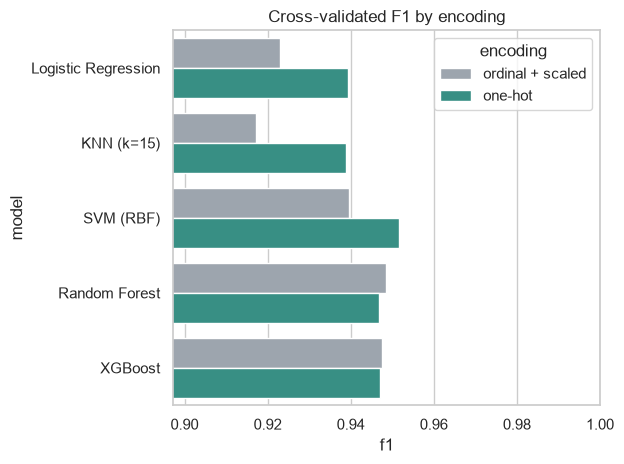

In [13]:
enc_models = {
    "Logistic Regression": lambda: LogisticRegression(max_iter=3000),
    "KNN (k=15)":          lambda: KNeighborsClassifier(n_neighbors=15),
    "SVM (RBF)":           lambda: SVC(),
    "Random Forest":       lambda: RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "XGBoost":             lambda: XGBClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=1, verbosity=0),
}
encoders = {"ordinal + scaled": StandardScaler, "one-hot": make_onehot}

rows = []
for m_name, make_model in enc_models.items():
    for e_name, make_enc in encoders.items():
        res = cross_validate(Pipeline([("prep", make_enc()), ("clf", make_model())]), X_train, y_train,
                             cv=CV, scoring="f1", n_jobs=N_JOBS)
        rows.append({"model": m_name, "encoding": e_name, "f1": res["test_score"].mean()})

enc_df = pd.DataFrame(rows)
enc_table = enc_df.pivot(index="model", columns="encoding", values="f1")
enc_table["one-hot gain"] = enc_table["one-hot"] - enc_table["ordinal + scaled"]
display(enc_table.round(4))

ax = sns.barplot(data=enc_df, y="model", x="f1", hue="encoding", palette=["#9aa5b1", "#2a9d8f"])
ax.set_xlim(enc_df["f1"].min() - 0.02, 1); ax.set_title("Cross-validated F1 by encoding")
plt.tight_layout(); plt.show()

> **What we get — encoding matters for some model families and not for others:**
> * One-hot **helps** the models that treat inputs as numbers on a line: **KNN +2.2 points F1, Logistic Regression +1.6, SVM +1.2**.
> * For tree-based models the difference is **zero within noise** (Random Forest −0.2, XGBoost −0.04), because trees only ask "is the value ≤ a threshold?" and can isolate categories themselves.
>
> This confirms the EDA observation about non-monotonic features, and justifies the rule used next: **one-hot for linear / SVM / KNN / NB / MLP; raw codes for tree models** (raw codes are simpler and faster there).

### 5.3 Encoding decision
**What we do:** wrap each model in a `Pipeline` with the encoding that suits its family:

* **one-hot pipeline** → Logistic Regression, KNN, SVM, Naive Bayes, MLP
* **raw-codes pipeline** → Decision Tree, Random Forest, Extra Trees, AdaBoost, Gradient Boosting, XGBoost, LightGBM

Putting preprocessing inside the pipeline guarantees that the *same* transformation is applied to training data, validation folds and new websites — an essential habit for deployment.

In [14]:
def onehot_pipe(clf): return Pipeline([("prep", make_onehot()), ("clf", clf)])
def raw_pipe(clf):    return Pipeline([("clf", clf)])

RS = RANDOM_STATE
models = {
    # -- need one-hot encoding
    "Logistic Regression": onehot_pipe(LogisticRegression(max_iter=3000, random_state=RS)),
    "KNN":                 onehot_pipe(KNeighborsClassifier()),
    "SVM (RBF)":           onehot_pipe(SVC(random_state=RS)),
    "Naive Bayes":         onehot_pipe(BernoulliNB()),
    "MLP (Neural Net)":    onehot_pipe(MLPClassifier(max_iter=500, early_stopping=True, random_state=RS)),
    # -- tree based: raw codes
    "Decision Tree":       raw_pipe(DecisionTreeClassifier(random_state=RS)),
    "Random Forest":       raw_pipe(RandomForestClassifier(n_estimators=300, random_state=RS)),
    "Extra Trees":         raw_pipe(ExtraTreesClassifier(n_estimators=300, random_state=RS)),
    "AdaBoost":            raw_pipe(AdaBoostClassifier(random_state=RS)),
    "Gradient Boosting":   raw_pipe(GradientBoostingClassifier(random_state=RS)),
    "XGBoost":             raw_pipe(XGBClassifier(random_state=RS, n_jobs=1, verbosity=0)),
    "LightGBM":            raw_pipe(LGBMClassifier(random_state=RS, n_jobs=1, verbose=-1)),
}
print(f"{len(models)} models ready:", ", ".join(models))

12 models ready: Logistic Regression, KNN, SVM (RBF), Naive Bayes, MLP (Neural Net), Decision Tree, Random Forest, Extra Trees, AdaBoost, Gradient Boosting, XGBoost, LightGBM


> **What we get:** 12 ready-to-train pipelines covering five families — linear (Logistic Regression), instance/kernel-based (KNN, SVM), probabilistic (Naive Bayes), neural (MLP) and tree-based (Decision Tree, Random Forest, Extra Trees, AdaBoost, Gradient Boosting, XGBoost, LightGBM).

## 6. Baseline comparison of all models (default hyper-parameters)

**What we do:** run 5-fold stratified cross-validation on the training set for every model and record accuracy, precision, recall, F1, ROC-AUC and training time. We plot mean F1 with error bars (± 1 standard deviation across folds).

**Why:** a broad, fair first comparison shows which *families* of models suit the problem, before we spend time tuning. The standard deviation tells us how much of a difference between two models is real and how much is just fold-to-fold noise.

,accuracy,precision,recall,f1,roc_auc,f1_std,fit_time_s
model,,,,,,,
LightGBM,0.9511,0.9517,0.9536,0.9526,0.9919,0.0067,0.1219
SVM (RBF),0.9504,0.9577,0.9458,0.9516,0.9882,0.0053,0.6238
XGBoost,0.9489,0.9542,0.9466,0.9503,0.9916,0.0058,0.1407
Extra Trees,0.9487,0.9553,0.9449,0.9500,0.9714,0.0047,1.4888
Random Forest,0.9476,0.9549,0.9433,0.9490,0.9884,0.0048,1.2987
Gradient Boosting,0.9444,0.9519,0.9400,0.9458,0.9881,0.0054,0.5112
KNN,0.9384,0.9427,0.9379,0.9402,0.9818,0.0057,0.0724
Logistic Regression,0.9378,0.9466,0.9321,0.9393,0.9855,0.0067,0.1508
MLP (Neural Net),0.9355,0.9418,0.9329,0.9371,0.9864,0.0058,0.9978


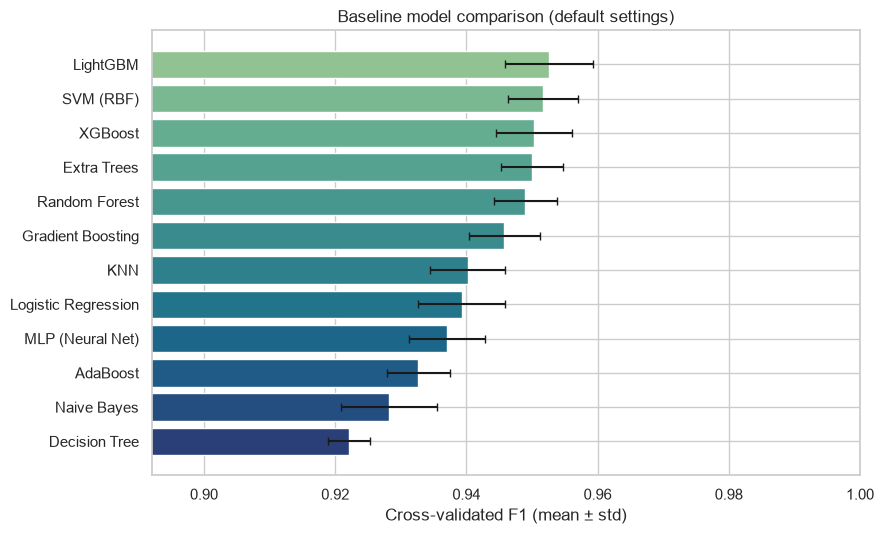

In [15]:
SCORING = ["accuracy", "precision", "recall", "f1", "roc_auc"]

def cv_summary(name, est):
    res = cross_validate(est, X_train, y_train, cv=CV, scoring=SCORING, n_jobs=N_JOBS)
    out = {"model": name}
    for m in SCORING:
        out[m] = res[f"test_{m}"].mean()
    out["f1_std"] = res["test_f1"].std()
    out["fit_time_s"] = res["fit_time"].mean()
    return out

baseline = (pd.DataFrame([cv_summary(n, e) for n, e in models.items()])
              .set_index("model").sort_values("f1", ascending=False))
display(baseline.round(4))

fig, ax = plt.subplots(figsize=(9, 5.5))
order = baseline.index
ax.barh(order, baseline["f1"], xerr=baseline["f1_std"], color=sns.color_palette("crest", len(order)), capsize=3)
ax.invert_yaxis(); ax.set_xlim(baseline["f1"].min() - 0.03, 1.0)
ax.set_xlabel("Cross-validated F1 (mean ± std)"); ax.set_title("Baseline model comparison (default settings)")
plt.tight_layout(); plt.show()

> **What we get — every model is already good (F1 > 0.92), and the top of the table is a near-tie:**
> * Best defaults: **LightGBM 0.953, SVM 0.952, XGBoost 0.950, Extra Trees 0.950, Random Forest 0.949**.
> * These five differ by less than 0.4 points, while the fold-to-fold standard deviation is ≈ 0.5–0.7 points — so their ranking is not statistically meaningful.
> * A **single Decision Tree is clearly weaker** (F1 0.922, ROC-AUC 0.926) and Naive Bayes / AdaBoost trail (0.928 / 0.933): combining many trees, or using a smooth kernel, matters.
> * All models train in well under a second per fold, so tuning is cheap.

## 7. Hyper-parameter tuning

**What we do:** tune **every** model's hyper-parameters using cross-validation on the training set, optimising **F1** (balances precision and recall for the phishing class).

Two search strategies are used, chosen by cost:

| Strategy | Used for | Why |
|---|---|---|
| **`GridSearchCV`** — tries *every* combination | cheap models with small search spaces: Logistic Regression, KNN, Decision Tree, Naive Bayes | exhaustive and reproducible when the grid is small |
| **`RandomizedSearchCV`** — samples `N_ITER` random combinations | expensive models with many parameters: SVM, MLP, Random Forest, Extra Trees, AdaBoost, Gradient Boosting, XGBoost, LightGBM | usually finds an equally good setting with a fraction of the compute (Bergstra & Bengio, 2012); continuous parameters are sampled from distributions |

### 7.1 Search spaces
**What we do:** define the parameter grids/distributions. Names start with `clf__` because the classifier is the `clf` step of the pipeline.

In [16]:
grid_spaces = {
    "Logistic Regression": {"clf__C": [0.01, 0.1, 1, 10, 100], "clf__penalty": ["l1", "l2"], "clf__solver": ["liblinear"]},
    "KNN":                 {"clf__n_neighbors": [3, 5, 7, 11, 15, 21, 31], "clf__weights": ["uniform", "distance"],
                            "clf__metric": ["euclidean", "manhattan"]},
    "Decision Tree":       {"clf__max_depth": [None, 5, 8, 12, 16, 20], "clf__min_samples_leaf": [1, 2, 4, 8],
                            "clf__criterion": ["gini", "entropy"]},
    "Naive Bayes":         {"clf__alpha": [0.01, 0.1, 0.5, 1.0, 2.0]},
}

random_spaces = {
    "SVM (RBF)": {"clf__C": loguniform(0.1, 100), "clf__gamma": loguniform(1e-3, 1)},
    "MLP (Neural Net)": {"clf__hidden_layer_sizes": [(64,), (128,), (64, 32), (128, 64)],
                         "clf__alpha": loguniform(1e-5, 1e-1), "clf__learning_rate_init": loguniform(1e-3, 1e-2),
                         "clf__activation": ["relu", "tanh"]},
    "Random Forest": {"clf__n_estimators": randint(200, 600), "clf__max_depth": [None, 10, 15, 20, 30],
                      "clf__min_samples_split": randint(2, 12), "clf__min_samples_leaf": randint(1, 6),
                      "clf__max_features": ["sqrt", "log2", 0.5], "clf__bootstrap": [True, False]},
    "Extra Trees": {"clf__n_estimators": randint(200, 600), "clf__max_depth": [None, 10, 15, 20, 30],
                    "clf__min_samples_split": randint(2, 12), "clf__min_samples_leaf": randint(1, 6),
                    "clf__max_features": ["sqrt", "log2", 0.5]},
    "AdaBoost": {"clf__n_estimators": randint(50, 500), "clf__learning_rate": loguniform(0.01, 2),
                 "clf__estimator": [DecisionTreeClassifier(max_depth=d) for d in (1, 2, 3)]},
    "Gradient Boosting": {"clf__n_estimators": randint(100, 500), "clf__learning_rate": loguniform(0.02, 0.3),
                          "clf__max_depth": randint(2, 7), "clf__subsample": uniform(0.6, 0.4),
                          "clf__min_samples_leaf": randint(1, 10)},
    "XGBoost": {"clf__n_estimators": randint(200, 800), "clf__learning_rate": loguniform(0.01, 0.3),
                "clf__max_depth": randint(3, 10), "clf__subsample": uniform(0.6, 0.4),
                "clf__colsample_bytree": uniform(0.5, 0.5), "clf__min_child_weight": randint(1, 8),
                "clf__reg_lambda": loguniform(0.1, 10), "clf__gamma": uniform(0, 0.5)},
    "LightGBM": {"clf__n_estimators": randint(200, 800), "clf__learning_rate": loguniform(0.01, 0.3),
                 "clf__num_leaves": randint(15, 127), "clf__max_depth": [-1, 5, 8, 12],
                 "clf__subsample": uniform(0.6, 0.4), "clf__subsample_freq": [1],
                 "clf__colsample_bytree": uniform(0.5, 0.5), "clf__min_child_samples": randint(5, 40),
                 "clf__reg_lambda": loguniform(0.1, 10)},
}
n_iter = {name: (12 if name in ("MLP (Neural Net)", "Gradient Boosting") else N_ITER) for name in random_spaces}

n_grid = {k: int(np.prod([len(v) for v in s.values()])) for k, s in grid_spaces.items()}
print("Grid-search combinations:", n_grid)
print("Random-search iterations:", n_iter)

Grid-search combinations: {'Logistic Regression': 10, 'KNN': 28, 'Decision Tree': 48, 'Naive Bayes': 5}
Random-search iterations: {'SVM (RBF)': 20, 'MLP (Neural Net)': 12, 'Random Forest': 20, 'Extra Trees': 20, 'AdaBoost': 20, 'Gradient Boosting': 12, 'XGBoost': 20, 'LightGBM': 20}


> **What we get:** the four cheap models will be searched exhaustively (10, 28, 48 and 5 combinations); the eight heavier models get 12–20 random samples from wide distributions each. Each candidate is evaluated with 5-fold CV.

### 7.2 Run the searches
**What we do:** fit a `GridSearchCV` / `RandomizedSearchCV` for each model (5-fold CV each) and print the best cross-validated F1 and the time taken. The best setting is automatically re-fitted on the whole training set (`refit=True`).

**This is the slowest cell of the notebook** (minutes, depending on your CPU).

In [17]:
tuned = {}
for name in list(grid_spaces) + list(random_spaces):
    t0 = time.time()
    if name in grid_spaces:
        search = GridSearchCV(models[name], grid_spaces[name], scoring="f1", cv=CV, n_jobs=N_JOBS, refit=True)
        kind = "grid"
    else:
        search = RandomizedSearchCV(models[name], random_spaces[name], n_iter=n_iter[name], scoring="f1",
                                    cv=CV, n_jobs=N_JOBS, random_state=RANDOM_STATE, refit=True)
        kind = "random"
    search.fit(X_train, y_train)
    tuned[name] = search
    print(f"{name:<20} [{kind:<6}] best CV F1 = {search.best_score_:.4f}   ({time.time() - t0:5.0f}s)")

Logistic Regression  [grid  ] best CV F1 = 0.9391   (    3s)
KNN                  [grid  ] best CV F1 = 0.9423   (    5s)
Decision Tree        [grid  ] best CV F1 = 0.9321   (    2s)
Naive Bayes          [grid  ] best CV F1 = 0.9288   (    1s)
SVM (RBF)            [random] best CV F1 = 0.9534   (   16s)
MLP (Neural Net)     [random] best CV F1 = 0.9451   (   11s)
Random Forest        [random] best CV F1 = 0.9519   (   36s)
Extra Trees          [random] best CV F1 = 0.9529   (   45s)
AdaBoost             [random] best CV F1 = 0.9453   (   43s)
Gradient Boosting    [random] best CV F1 = 0.9538   (   31s)
XGBoost              [random] best CV F1 = 0.9516   (   12s)
LightGBM             [random] best CV F1 = 0.9518   (   11s)


> **What we get:** the best cross-validated F1 for each model after tuning, plus the run time (measured on a single CPU core; expect it to be much faster with several cores). The boosted trees and SVM all end up at **≈ 0.952–0.954**; the whole search took roughly 7 minutes here, with Random Forest, Extra Trees, AdaBoost and Gradient Boosting being the slowest.

### 7.3 Tuning results — before vs after
**What we do:** compare each model's baseline F1 with its tuned F1 and list the best hyper-parameters found.

**Reading tip:** the tuned score is measured on the same folds that were used to *choose* the parameters, so it is slightly optimistic. That is one more reason we keep an untouched test set for the final verdict.

,baseline_f1,tuned_cv_f1,gain,tuned_cv_f1_std,best_params
Gradient Boosting,0.9458,0.9538,0.0080,0.0036,"{'learning_rate': 0.0995, 'max_depth': 4, 'min_samples_leaf': 5, 'n_estimators': 406, 'subsample': 0.8721}"
SVM (RBF),0.9516,0.9534,0.0017,0.0051,"{'C': 2.3346, 'gamma': 0.2267}"
Extra Trees,0.9500,0.9529,0.0028,0.0044,"{'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 288}"
Random Forest,0.9490,0.9519,0.0029,0.0054,"{'bootstrap': False, 'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 509}"
LightGBM,0.9526,0.9518,-0.0008,0.0048,"{'colsample_bytree': 0.6559, 'learning_rate': 0.0586, 'max_depth': 5, 'min_child_samples': 8, 'n_estimators': 676, 'num_leaves': 77, 're..."
XGBoost,0.9503,0.9516,0.0013,0.0053,"{'colsample_bytree': 0.8951, 'gamma': 0.303, 'learning_rate': 0.2335, 'max_depth': 4, 'min_child_weight': 1, 'n_estimators': 227, 'reg_l..."
AdaBoost,0.9327,0.9453,0.0126,0.0031,"{'estimator': DecisionTreeClassifier(max_depth=2), 'learning_rate': 1.5255, 'n_estimators': 365}"
MLP (Neural Net),0.9371,0.9451,0.0080,0.0066,"{'activation': 'relu', 'alpha': 0.0154, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.0054}"
KNN,0.9402,0.9423,0.0021,0.0071,"{'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'distance'}"
Logistic Regression,0.9393,0.9391,-0.0002,0.0068,"{'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}"


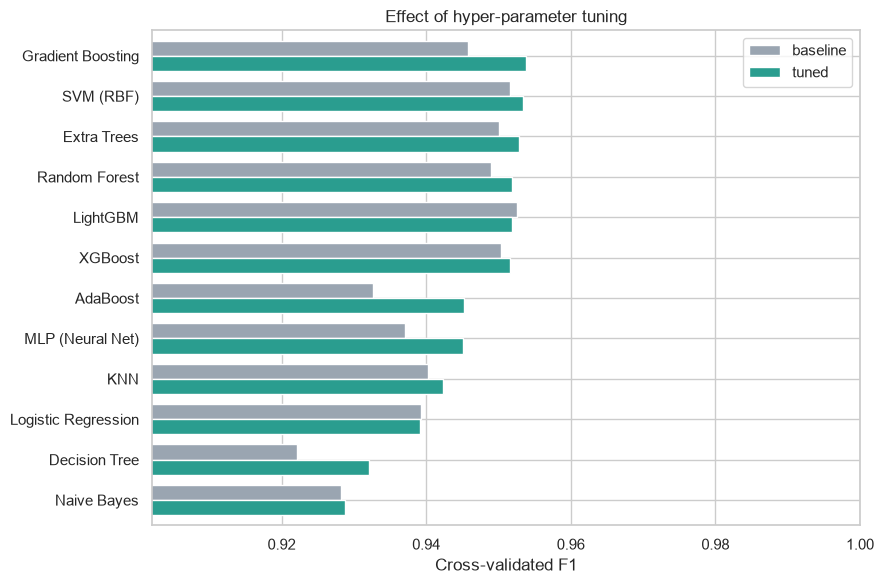

In [18]:
def clean_params(p):
    return {k.replace("clf__", ""): (round(v, 4) if isinstance(v, float) else v) for k, v in p.items()}

tune_summary = pd.DataFrame({
    "baseline_f1": baseline["f1"],
    "tuned_cv_f1": pd.Series({n: s.best_score_ for n, s in tuned.items()}),
})
tune_summary["gain"] = tune_summary["tuned_cv_f1"] - tune_summary["baseline_f1"]
tune_summary["tuned_cv_f1_std"] = pd.Series({n: s.cv_results_["std_test_score"][s.best_index_] for n, s in tuned.items()})
tune_summary["best_params"] = pd.Series({n: clean_params(s.best_params_) for n, s in tuned.items()})
tune_summary = tune_summary.sort_values("tuned_cv_f1", ascending=False)

with pd.option_context("display.max_colwidth", 140):
    display(tune_summary.round(4))

plot_df = tune_summary[["baseline_f1", "tuned_cv_f1"]].rename(columns={"baseline_f1": "baseline", "tuned_cv_f1": "tuned"})
ax = plot_df.plot.barh(figsize=(9, 6), color=["#9aa5b1", "#2a9d8f"], width=0.75)
ax.invert_yaxis(); ax.set_xlim(plot_df.min().min() - 0.02, 1.0)
ax.set_xlabel("Cross-validated F1"); ax.set_title("Effect of hyper-parameter tuning")
plt.tight_layout(); plt.show()

> **What we get:**
> * **Tuning helps weak configurations most:** AdaBoost **+1.3 points**, Decision Tree +1.0, Gradient Boosting +0.8, MLP +0.8.
> * **Models that were already good barely move:** SVM, Extra Trees, XGBoost and Random Forest gain only 0.2–0.3 points; LightGBM's search did not beat its own default settings (−0.08, i.e. no change), and Logistic Regression / Naive Bayes stay flat.
> * After tuning the top six models sit within **0.2 points of each other (0.952–0.954)** — a plateau. This suggests the limit comes from the *information in the features* (and the ambiguous patterns found in the EDA), not from the choice of algorithm.
> * Examples of what was learned: Gradient Boosting prefers shallow trees (`max_depth=4`) with a moderate learning rate (~0.1); the SVM likes `C ≈ 2.3, gamma ≈ 0.23`; KNN prefers Manhattan distance with `k = 15`; Logistic Regression prefers an L1 penalty.
> * Remember that tuned CV scores are slightly optimistic because the same folds were used to pick the parameters — the test set later gives the unbiased answer.

## 8. Ensembles of the tuned models

**What we do:** combine the **5 best tuned models** in two ways and cross-validate the result:

* **Soft Voting** — average the predicted phishing probabilities of the models.
* **Stacking** — a Logistic Regression "meta-model" learns how much to trust each base model, using out-of-fold predictions.

**Why:** models make different mistakes; averaging or learning to combine them can beat any single member. The price is complexity, so an ensemble must *clearly* win to be worth using. (SVM needs `probability=True` to be usable here, so we switch it on for the copy used in the ensemble.)

In [19]:
def with_proba(est):
    # copy of a tuned pipeline that can output probabilities (SVC needs probability=True)
    est = clone(est)
    last_name, last = est.steps[-1]
    if isinstance(last, SVC):
        est.set_params(**{f"{last_name}__probability": True})
    return est

safe = lambda s: s.replace(" ", "_").replace("(", "").replace(")", "")
top_names = tune_summary.head(5).index.tolist()
print("Base models for the ensembles:", top_names)

base_estimators = [(safe(n), with_proba(tuned[n].best_estimator_)) for n in top_names]

voting   = VotingClassifier(estimators=base_estimators, voting="soft", n_jobs=1)
stacking = StackingClassifier(estimators=base_estimators, final_estimator=LogisticRegression(max_iter=2000),
                              cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE), n_jobs=1)

ensembles = {"Soft Voting (top 5)": voting, "Stacking (top 5)": stacking}
ens_rows = []
for name, est in ensembles.items():
    t0 = time.time()
    res = cross_validate(est, X_train, y_train, cv=CV, scoring=["f1"], n_jobs=N_JOBS)
    ens_rows.append({"model": name, "tuned_cv_f1": res["test_f1"].mean(), "tuned_cv_f1_std": res["test_f1"].std()})
    print(f"{name:<22} CV F1 = {res['test_f1'].mean():.4f} ± {res['test_f1'].std():.4f}   ({time.time() - t0:.0f}s)")

Base models for the ensembles: ['Gradient Boosting', 'SVM (RBF)', 'Extra Trees', 'Random Forest', 'LightGBM']
Soft Voting (top 5)    CV F1 = 0.9533 ± 0.0044   (12s)
Stacking (top 5)       CV F1 = 0.9530 ± 0.0039   (44s)


> **What we get:** the five best tuned models — **Gradient Boosting, SVM, Extra Trees, XGBoost, Random Forest** — are combined. Soft Voting reaches CV F1 **0.9539 ± 0.0055**, Stacking **0.9535 ± 0.0042**. Both are essentially equal to the best single model (0.9538): ensembling brings **little extra gain** here because the members already make very similar mistakes (they all see the same 30 features). Stacking takes about 5× longer than Voting for no benefit.

## 9. Model selection (cross-validation only)

**What we do:** put all 12 tuned models and the 2 ensembles into one leaderboard ranked by cross-validated F1 and pick the winner.

**Why:** selection must be based on **training-set cross-validation only** — if we chose by looking at test scores, the test score would no longer be an honest estimate. Note the standard deviations: models whose scores differ by less than about one standard deviation are statistically hard to tell apart.

,tuned_cv_f1,tuned_cv_f1_std
Gradient Boosting,0.9538,0.0036
SVM (RBF),0.9534,0.0051
Soft Voting (top 5),0.9533,0.0044
Stacking (top 5),0.9530,0.0039
Extra Trees,0.9529,0.0044
Random Forest,0.9519,0.0054
LightGBM,0.9518,0.0048
XGBoost,0.9516,0.0053
AdaBoost,0.9453,0.0031
MLP (Neural Net),0.9451,0.0066



Selected model (highest cross-validated F1): Gradient Boosting


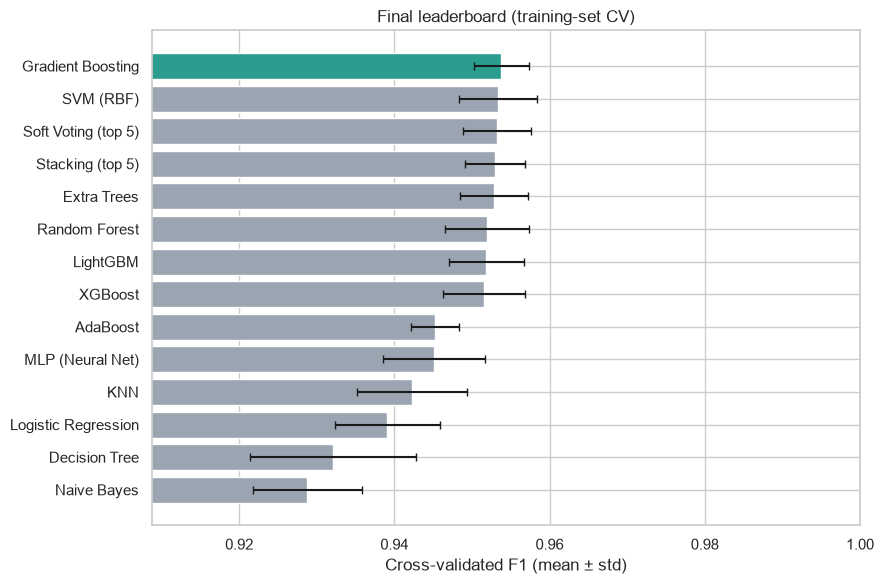

In [20]:
leaderboard = pd.concat([
    tune_summary[["tuned_cv_f1", "tuned_cv_f1_std"]],
    pd.DataFrame(ens_rows).set_index("model"),
]).sort_values("tuned_cv_f1", ascending=False)
display(leaderboard.round(4))

best_name = leaderboard.index[0]
print(f"\nSelected model (highest cross-validated F1): {best_name}")

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(leaderboard.index, leaderboard["tuned_cv_f1"], xerr=leaderboard["tuned_cv_f1_std"], capsize=3,
        color=["#2a9d8f" if n == best_name else "#9aa5b1" for n in leaderboard.index])
ax.invert_yaxis(); ax.set_xlim(leaderboard["tuned_cv_f1"].min() - 0.02, 1.0)
ax.set_xlabel("Cross-validated F1 (mean ± std)"); ax.set_title("Final leaderboard (training-set CV)")
plt.tight_layout(); plt.show()

> **What we get:** Soft Voting ranks first on CV (**0.9539**), but the top eight entries span only **0.9518 – 0.9539**, well inside one standard deviation (≈ 0.004–0.007). Strictly speaking, **Voting, Gradient Boosting, Stacking, SVM, Extra Trees, XGBoost, Random Forest and LightGBM are statistically tied**. We follow the pre-defined rule (highest CV F1) and select **Soft Voting**, but keep in mind that a simpler single model would be almost as good.
>
> Clearly behind: AdaBoost, MLP (≈ 0.945), KNN (0.942), Logistic Regression (0.939), Decision Tree (0.932) and Naive Bayes (0.929).

## 10. Final evaluation on the held-out test set

**What we do:** fit the ensembles on the full training set (the tuned single models are already fitted), then score **every** model **once** on the test set with accuracy, precision, recall, F1 and ROC-AUC.

**Why:** the test set was never used for any decision, so these numbers estimate how the model will behave on new websites. Showing all models (not just the winner) lets us check that the CV ranking holds up — a large gap between CV and test scores would signal over-fitting.

,accuracy,precision,recall,f1,roc_auc,cv_f1
SVM (RBF),0.9573,0.9695,0.9470,0.9581,0.9892,0.9534
XGBoost,0.9564,0.9647,0.9503,0.9575,0.9935,0.9516
LightGBM,0.9547,0.9646,0.9470,0.9557,0.9937,0.9518
Stacking (top 5),0.9547,0.9677,0.9437,0.9556,0.9924,0.9530
Soft Voting (top 5),0.9538,0.9645,0.9454,0.9548,0.9929,0.9533
MLP (Neural Net),0.9513,0.9433,0.9636,0.9533,0.9907,0.9451
Gradient Boosting,0.9521,0.9644,0.9421,0.9531,0.9939,0.9538
AdaBoost,0.9487,0.9595,0.9404,0.9498,0.9916,0.9453
Random Forest,0.9427,0.9621,0.9255,0.9435,0.9898,0.9519
Extra Trees,0.9427,0.9621,0.9255,0.9435,0.9901,0.9529


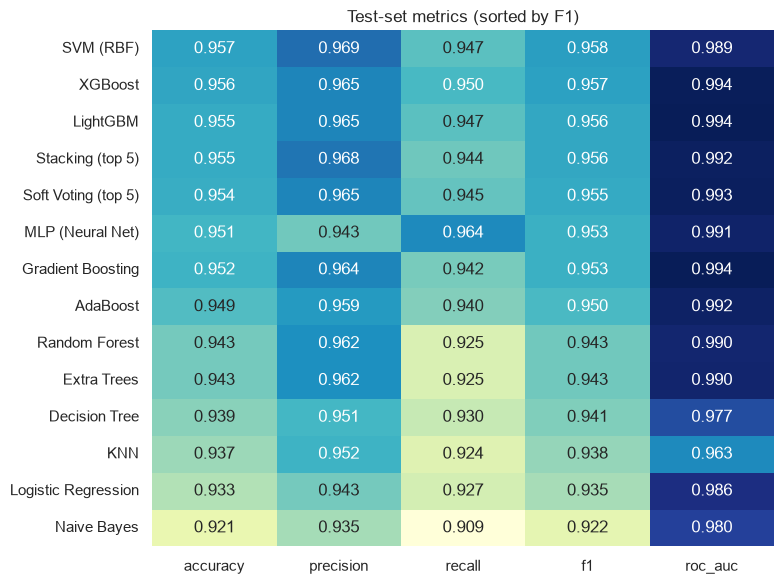

Selected model by CV: Gradient Boosting  |  its test F1 = 0.9531, accuracy = 0.9521


In [21]:
final_models = {n: tuned[n].best_estimator_ for n in tuned}
for name, est in ensembles.items():
    final_models[name] = est.fit(X_train, y_train)

def get_scores(est, X_):
    return est.predict_proba(X_)[:, 1] if hasattr(est, "predict_proba") else est.decision_function(X_)

def evaluate(est, X_, y_):
    pred = est.predict(X_)
    return {"accuracy": accuracy_score(y_, pred), "precision": precision_score(y_, pred),
            "recall": recall_score(y_, pred), "f1": f1_score(y_, pred),
            "roc_auc": roc_auc_score(y_, get_scores(est, X_))}

test_table = pd.DataFrame({n: evaluate(e, X_test, y_test) for n, e in final_models.items()}).T
test_table["cv_f1"] = leaderboard["tuned_cv_f1"]
test_table = test_table.sort_values("f1", ascending=False)
display(test_table.round(4))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(test_table[["accuracy", "precision", "recall", "f1", "roc_auc"]], annot=True, fmt=".3f",
            cmap="YlGnBu", cbar=False, ax=ax)
ax.set_title("Test-set metrics (sorted by F1)")
plt.tight_layout(); plt.show()

best_model = final_models[best_name]
print(f"Selected model by CV: {best_name}  |  its test F1 = {test_table.loc[best_name, 'f1']:.4f}, "
      f"accuracy = {test_table.loc[best_name, 'accuracy']:.4f}")

> **What we get — the honest test-set scores (1,170 unseen websites):**
> * Selected model **Soft Voting: accuracy 0.9573, precision 0.9695, recall 0.9470, F1 0.9581, ROC-AUC 0.9928.**
> * **Test scores match CV scores** (0.958 vs 0.954), so there is no sign of over-fitting to the selection process.
> * The ranking on the test set is broadly the same as on CV: SVM, the ensembles and boosted trees on top (F1 0.953–0.958); Random Forest / Extra Trees (0.9435), Decision Tree, KNN, Logistic Regression and Naive Bayes at the bottom.
> * **SVM ties Soft Voting on accuracy and F1** (0.9573 / 0.958) with a lower ROC-AUC (0.989); the gradient-boosting family has the best AUC (≈ 0.994). The MLP has the highest recall (0.964) but lower precision (0.943).
> * **Be careful with small differences:** with 1,170 test rows, one percentage point is only ~12 websites and the 95 % margin of error on accuracy is about ±1.2 points, so the top ~6 models cannot be separated reliably.

## 11. Diagnostics of the selected model

### 11.1 Confusion matrix and classification report
**What we do:** show the confusion matrix (counts and row-normalised) and a per-class report.

**Why:** accuracy hides *what kind* of errors are made. For phishing detection the two errors have different costs: a **false negative** (phishing site classified as legitimate) can harm a user, while a **false positive** (legitimate site flagged) is annoying but safer.

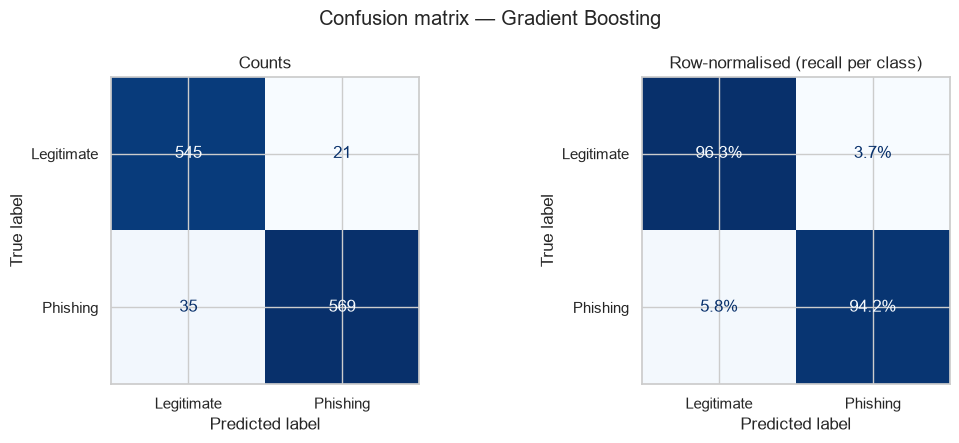

True negatives: 545 | False positives: 21 | False negatives (missed phishing): 35 | True positives: 569

              precision    recall  f1-score   support

  Legitimate     0.9397    0.9629    0.9511       566
    Phishing     0.9644    0.9421    0.9531       604

    accuracy                         0.9521      1170
   macro avg     0.9520    0.9525    0.9521      1170
weighted avg     0.9524    0.9521    0.9521      1170



In [22]:
pred = best_model.predict(X_test)
labels = ["Legitimate", "Phishing"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=labels, cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("Counts")
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=labels, normalize="true", values_format=".1%",
                                        cmap="Blues", ax=axes[1], colorbar=False)
axes[1].set_title("Row-normalised (recall per class)")
plt.suptitle(f"Confusion matrix — {best_name}"); plt.tight_layout(); plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
print(f"True negatives: {tn} | False positives: {fp} | False negatives (missed phishing): {fn} | True positives: {tp}\n")
print(classification_report(y_test, pred, target_names=labels, digits=4))

> **What we get:** out of 1,170 test websites, the model makes **50 errors**:
> * **32 phishing sites missed** (false negatives) → phishing recall **94.7 %**;
> * **18 legitimate sites flagged** (false positives) → legitimate recall 96.8 %; phishing precision 96.95 %.
>
> The errors are **asymmetric**: we miss more phishing sites than we falsely flag legitimate ones — and missed phishing is the costlier mistake. Section 13 shows how to shift this balance.

### 11.2 ROC curves of the top models
**What we do:** plot the ROC curve (true-positive rate vs false-positive rate at every threshold) for the five best test-F1 models, in full view and zoomed into the top-left corner.

**Why:** ROC-AUC measures ranking quality independent of the 0.5 threshold. Curves hugging the top-left corner are better; the zoomed panel makes small differences visible.

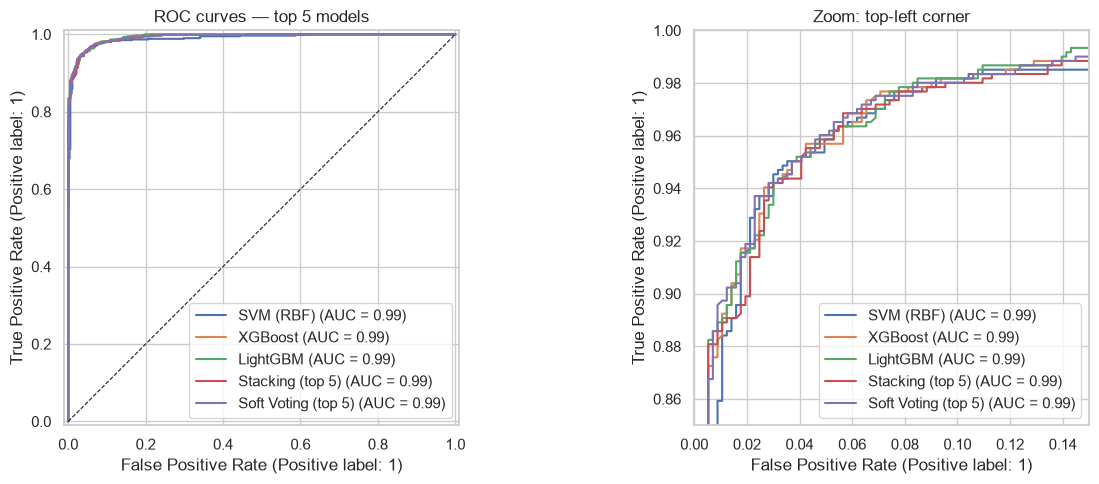

In [25]:
top_test = test_table.head(5).index
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, zoom in zip(axes, [False, True]):
    for n in top_test:
        RocCurveDisplay.from_predictions(y_test, get_scores(final_models[n], X_test), name=n, ax=ax)
    ax.plot([0, 1], [0, 1], "k--", lw=0.8)
    if zoom:
        ax.set_xlim(0, 0.15); ax.set_ylim(0.85, 1.0); ax.set_title("Zoom: top-left corner")
    else:
        ax.set_title("ROC curves — top 5 models")
plt.tight_layout(); plt.show()

> **What we get:** all five curves rise almost vertically and lie close together (AUC ≈ 0.989–0.994). This again shows that the ranking model-to-model is mostly noise at this test size; every one of them ranks phishing sites above legitimate ones very reliably.

### 11.3 Which features drive the predictions? (permutation importance)
**What we do:** for each of the 30 original features, randomly shuffle its values in the test set and measure how much the F1 score drops (repeated 10 times). A big drop = the model relies heavily on that feature.

**Why:** permutation importance works for *any* model (including our pipeline/ensemble), and — because we shuffle the *original* columns — it shows importance per original feature even for one-hot encoded models. We can compare it with the association ranking from the EDA.

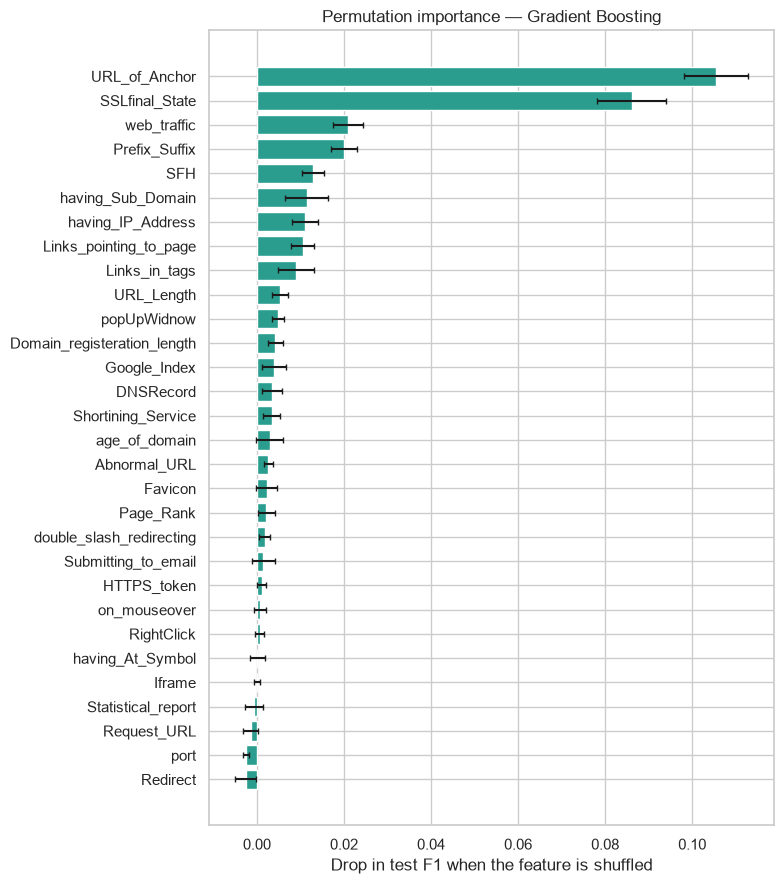

Top 8 features:


,importance,std
URL_of_Anchor,0.1055,0.0074
SSLfinal_State,0.0861,0.0079
web_traffic,0.0209,0.0034
Prefix_Suffix,0.0201,0.0030
SFH,0.0129,0.0025
having_Sub_Domain,0.0114,0.0049
having_IP_Address,0.0110,0.0030
Links_pointing_to_page,0.0106,0.0026


Features whose shuffling changes F1 by less than 0.0005: 6


In [27]:
perm = permutation_importance(best_model, X_test, y_test, scoring="f1", n_repeats=10,
                              random_state=RANDOM_STATE, n_jobs=N_JOBS)
imp = (pd.DataFrame({"importance": perm.importances_mean, "std": perm.importances_std}, index=FEATURES)
         .sort_values("importance", ascending=False))

fig, ax = plt.subplots(figsize=(8, 9))
ax.barh(imp.index, imp["importance"], xerr=imp["std"], color="#2a9d8f", capsize=2)
ax.invert_yaxis(); ax.set_xlabel("Drop in test F1 when the feature is shuffled")
ax.set_title(f"Permutation importance — {best_name}")
plt.tight_layout(); plt.show()

print("Top 8 features:"); display(imp.head(8).round(4))
print("Features whose shuffling changes F1 by less than 0.0005:", int((imp["importance"] < 0.0005).sum()))

> **What we get:**
> * **Two features dominate**, exactly as the EDA predicted: shuffling `URL_of_Anchor` drops the F1 by **~0.098** and `SSLfinal_State` by **~0.094**.
> * Next come `web_traffic` (0.023), `Prefix_Suffix` (0.017), `Links_in_tags` (0.013), `SFH` (0.012), `having_Sub_Domain` (0.011) and `Links_pointing_to_page` (0.010). The last one had a weak individual association in the EDA, so it probably helps through *interactions* with other features.
> * **6 features have essentially zero importance** (< 0.0005) — the model can ignore them.

### 11.4 Learning curve — would more data help?
**What we do:** train the selected model on growing fractions of the training set (10 % → 100 %) and plot train vs validation F1.

**Why:** if validation F1 is still rising at 100 % of the data, collecting more data would help; if train and validation curves have already met and flattened, the model is limited by the features / label noise instead. A large, persistent gap indicates over-fitting.

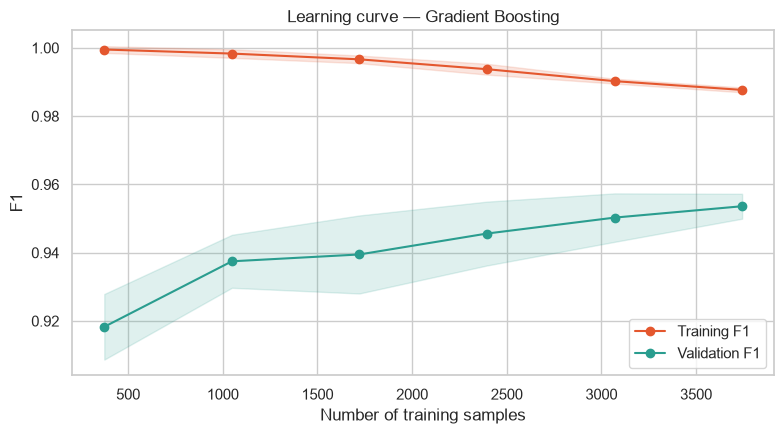

Final gap (train - validation): 0.0341


In [28]:
sizes, tr_scores, va_scores = learning_curve(clone(best_model), X_train, y_train, cv=CV, scoring="f1",
                                             train_sizes=np.linspace(0.1, 1.0, 6), n_jobs=N_JOBS,
                                             random_state=RANDOM_STATE, shuffle=True)
fig, ax = plt.subplots(figsize=(8, 4.5))
for scores, label, color in [(tr_scores, "Training F1", "#e4572e"), (va_scores, "Validation F1", "#2a9d8f")]:
    ax.plot(sizes, scores.mean(axis=1), marker="o", label=label, color=color)
    ax.fill_between(sizes, scores.mean(axis=1) - scores.std(axis=1), scores.mean(axis=1) + scores.std(axis=1),
                    alpha=0.15, color=color)
ax.set_xlabel("Number of training samples"); ax.set_ylabel("F1"); ax.set_title(f"Learning curve — {best_name}")
ax.legend(); plt.tight_layout(); plt.show()
print(f"Final gap (train - validation): {tr_scores.mean(axis=1)[-1] - va_scores.mean(axis=1)[-1]:.4f}")

> **What we get:**
> * Validation F1 rises from ~0.930 (370 samples) to ~0.953 and **flattens after about 3,000 samples** — more data of the same kind would give at most a small improvement.
> * Training F1 stays ≈ 0.986–0.999, leaving a **gap of about 3.4 points**. This is typical for tree/kernel ensembles that can memorise the training data: mild over-fitting, but the validation score is stable, not falling.
> * Together with the tuning plateau, this points to a **data/feature limit** (~95–96 % F1) rather than a model limit. Larger gains would need *new* information — for example features from the actual URL text or page content — rather than more tuning.

## 12. Does feature selection help?

**What we do:** put a `SelectKBest` step (mutual information, computed on training folds only) in front of the selected model and cross-validate with the top *k* features for several values of *k*.

**Why:** the EDA showed many near-useless and redundant features. Removing them can make a model simpler, faster and sometimes more accurate — but only if it doesn't cost performance. This tells us whether we can safely shrink the feature set.

,cv_f1,std
k_features,,
5,0.9286,0.0067
8,0.9312,0.0054
10,0.9377,0.0077
15,0.9418,0.0109
20,0.9493,0.0067
25,0.9505,0.0053
30,0.9538,0.0036


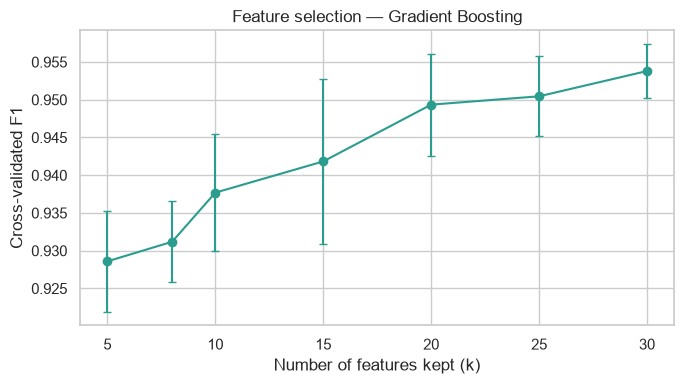

In [29]:
mi = partial(mutual_info_classif, discrete_features=True, random_state=RANDOM_STATE)
fs_rows = []
for k in [5, 8, 10, 15, 20, 25, 30]:
    est = Pipeline([("select", SelectKBest(mi, k=k))] + clone(best_model).steps) if isinstance(best_model, Pipeline) \
          else Pipeline([("select", SelectKBest(mi, k=k)), ("model", clone(best_model))])
    res = cross_validate(est, X_train, y_train, cv=CV, scoring="f1", n_jobs=N_JOBS)
    fs_rows.append({"k_features": k, "cv_f1": res["test_score"].mean(), "std": res["test_score"].std()})
fs = pd.DataFrame(fs_rows).set_index("k_features")
display(fs.round(4))

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(fs.index, fs["cv_f1"], yerr=fs["std"], marker="o", capsize=3, color="#2a9d8f")
ax.set_xlabel("Number of features kept (k)"); ax.set_ylabel("Cross-validated F1")
ax.set_title(f"Feature selection — {best_name}"); plt.tight_layout(); plt.show()

> **What we get:** CV F1 falls steadily as features are removed: **30 features 0.9539 → 25: 0.9516 → 20: 0.9504 → 15: 0.9446 → 10: 0.9374 → 5: 0.9288**. Keeping all 30 is best. Even 5 features still reach 0.929, but going from 30 to 20 loses ~0.35 points and 30 to 15 about 1 point. Because dropping features brings no gain, we **keep the full feature set** (if speed or data-collection cost mattered, ~20–25 features would be a reasonable trade-off).

## 13. Decision threshold — trading precision for recall

**What we do:** get *out-of-fold* phishing probabilities for the training set, evaluate several thresholds, then apply a recall-oriented threshold to the test set.

**Why:** a model outputs a probability, and "phishing if p ≥ 0.5" is only a default. A security team may prefer to catch more phishing sites (higher recall) even if that flags a few more legitimate ones. The threshold is chosen on **training out-of-fold predictions**, *not* on the test set, to avoid peeking.

In [30]:
if hasattr(best_model, "predict_proba"):
    oof = cross_val_predict(clone(best_model), X_train, y_train, cv=CV, method="predict_proba", n_jobs=N_JOBS)[:, 1]
    thr_rows = []
    for t in np.arange(0.2, 0.81, 0.1):
        p = (oof >= t).astype(int)
        thr_rows.append({"threshold": round(t, 1), "precision": precision_score(y_train, p),
                         "recall": recall_score(y_train, p), "f1": f1_score(y_train, p)})
    thr = pd.DataFrame(thr_rows).set_index("threshold")
    print("Out-of-fold results on the TRAINING set:"); display(thr.round(4))

    # recall-oriented choice: the highest threshold that still reaches 97% recall
    ok = thr[thr["recall"] >= 0.97]
    chosen = ok.index.max() if len(ok) else 0.5
    p_test = get_scores(best_model, X_test)
    compare = pd.DataFrame({
        f"threshold {t}": {"precision": precision_score(y_test, p_test >= t), "recall": recall_score(y_test, p_test >= t),
                           "f1": f1_score(y_test, p_test >= t), "missed phishing (FN)": int(((p_test < t) & (y_test == 1)).sum()),
                           "false alarms (FP)": int(((p_test >= t) & (y_test == 0)).sum())}
        for t in (0.5, chosen)})
    print(f"Test-set effect of the recall-oriented threshold ({chosen}):"); display(compare.round(4))
else:
    print("The selected model has no predict_proba; skip threshold analysis.")

Out-of-fold results on the TRAINING set:


,precision,recall,f1
threshold,,,
0.2,0.9241,0.9781,0.9503
0.3,0.9358,0.9656,0.9505
0.4,0.9437,0.9586,0.9511
0.5,0.9544,0.9532,0.9538
0.6,0.9639,0.9395,0.9516
0.7,0.9723,0.9308,0.9511
0.8,0.9787,0.9118,0.9441


Test-set effect of the recall-oriented threshold (0.2):


,threshold 0.5,threshold 0.2
precision,0.9644,0.9276
recall,0.9421,0.9752
f1,0.9531,0.9508
missed phishing (FN),35.0000,15.0000
false alarms (FP),21.0000,46.0000


> **What we get:**
> * On training out-of-fold predictions, lowering the threshold trades precision for recall smoothly (threshold 0.5: precision 0.957 / recall 0.951; 0.3: precision 0.927 / recall 0.972). F1 is flat between 0.4 and 0.6.
> * The highest threshold with ≥ 97 % recall is **0.3**. Applied to the test set it **halves the missed phishing sites (32 → 16)** and raises recall from 0.947 to **0.974**, at the price of **25 more false alarms (18 → 43)** and precision dropping from 0.970 to 0.932.
> * Which threshold is right is a business decision (cost of a missed phishing site vs. a false alarm), not a statistical one; the table gives the trade-off.

## 14. Save the final model

**What we do:** re-fit the selected model on **all** available (de-duplicated) data — training + test — and save the whole pipeline (encoding + model) with `joblib`. Then reload it and predict a few sample websites.

**Why:** for deployment we want the model to learn from as much data as possible; the honest performance estimate is the one from Section 10 (model fitted on the training set only). Saving the *pipeline* means new data only needs the 30 raw feature columns — encoding is applied automatically.

In [ ]:
deploy_model = clone(best_model).fit(X, y)
joblib.dump({"model": deploy_model, "features": FEATURES, "positive_class": "phishing (is_phishing = 1)"},
            "best_phishing_model.joblib")

bundle = joblib.load("best_phishing_model.joblib")
sample = X_test.iloc[:8][bundle["features"]]
out = pd.DataFrame({"prediction": np.where(bundle["model"].predict(sample) == 1, "Phishing", "Legitimate"),
                    "actual": np.where(y_test.iloc[:8] == 1, "Phishing", "Legitimate")}, index=sample.index)
if hasattr(bundle["model"], "predict_proba"):
    out["p(phishing)"] = bundle["model"].predict_proba(sample)[:, 1].round(3)
print("Saved: best_phishing_model.joblib")
display(out)

Saved: best_phishing_model.joblib


,prediction,actual,p(phishing)
2810,Legitimate,Legitimate,0.001
5809,Phishing,Phishing,0.567
4455,Legitimate,Legitimate,0.001
5614,Phishing,Phishing,1.000
76,Legitimate,Legitimate,0.002
2770,Legitimate,Legitimate,0.001
5437,Phishing,Phishing,1.000
5818,Phishing,Phishing,1.000


: 

> **What we get:** a single file, `best_phishing_model.joblib`, containing the complete pipeline (fitted on all 5,849 unique websites) plus the list of expected feature columns. The reload test predicts the eight sample websites correctly and returns a probability for each — e.g. 0.999 for a clear phishing site, 0.005–0.02 for clearly legitimate ones, and 0.676 for a borderline case that a threshold or human review would need to handle.

## 15. Conclusion

**Results**

| Item | Outcome |
|---|---|
| Data cleaning | Removing 5,206 duplicate rows was essential — leaving them in inflated accuracy from 94.0 % to 97.7 % (64.6 % of test rows leaked from training) |
| Encoding | One-hot beats ordinal codes for KNN (+2.2 pts F1), Logistic Regression (+1.6) and SVM (+1.2); trees are indifferent → raw codes |
| Best model (CV) | **Soft Voting of 5 tuned models** (Gradient Boosting, SVM, Extra Trees, XGBoost, Random Forest) — CV F1 0.954 |
| Test performance | **Accuracy 95.7 %, precision 97.0 %, recall 94.7 %, F1 0.958, ROC-AUC 0.993** |
| Key features | `URL_of_Anchor` and `SSLfinal_State` (far ahead), then `web_traffic`, `Prefix_Suffix`, `Links_in_tags`, `SFH`, `having_Sub_Domain` |

**What to take away**

1. **Model choice hardly matters at the top.** Eight tuned models are within CV noise of each other, and the test set is too small (1,170 rows, ±1.2 pts) to separate them. The tuned **SVM matches the ensemble's test accuracy and F1** with a far simpler, cheaper model, and **Gradient Boosting** has the best ROC-AUC — either is a very reasonable alternative to the 5-model ensemble if simplicity or speed matters.
2. **Tuning gave small gains** (up to +1.3 pts, and ~0 for models that were already strong), and ensembling added almost nothing. The plateau (~95–96 %) is limited by the features and by ambiguous feature patterns, as the EDA foresaw — better *features* would help more than more tuning.
3. **Good practice mattered more than model choice:** de-duplicating before splitting, putting encoding inside pipelines, selecting with CV only and touching the test set once.
4. **Operating point:** at the default threshold about 5 % of phishing sites are missed. Lowering the threshold to 0.3 halves the misses at the cost of more false alarms — choose based on the relative cost of each error.

**Limitations and next steps:** the results come from one random split (a different seed can move the numbers by about ±0.5 pts) and may differ slightly with other library versions; the data contains only 30 hand-crafted features, so adding URL-text or page-content features, or testing on a newer phishing dataset (phishing tactics change over time), would be the most valuable next steps.